### Guest voice, review embeddings
* sentence embeddings of recent Lisbon Airbnb reviews with a small local model on cpu
* clustering into topics, sentiment lexicon score per topic and per neighbourhood
* exports embeddings and topic tables for the semantic search endpoint

In [1]:
import os
import re
import json
import datetime
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
warnings.filterwarnings("ignore")

ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
REVIEWS_PATH = os.path.join(ROOT_DIR, "data", "parquet", "airbnb_reviews_sample.parquet")
LISTINGS_PATH = os.path.join(ROOT_DIR, "data", "parquet", "airbnb_listings.parquet")
MODELS_DIR = os.path.join(ROOT_DIR, "data", "models")
model_name = "sentence-transformers/all-MiniLM-L6-v2"
max_reviews = 60000
n_topics = 14

In [2]:
# load reviews, keep english looking texts, strip html and cap the sample
def load_reviews(path, limit):
    frame = pd.read_parquet(path)
    frame["text"] = frame["comments"].str.replace(r"<br\s*/?>", " ", regex=True).str.replace(r"\s+", " ", regex=True).str.strip()
    english = frame["text"].str.contains(r"\b(?:the|and|was|very|great|stay|place|host)\b", case=False, regex=True)
    frame = frame[english & (frame["text"].str.len() >= 60) & (frame["text"].str.len() <= 1200)]
    frame = frame.sample(min(limit, len(frame)), random_state=7).reset_index(drop=True)
    frame["text"] = frame["text"].str.slice(0, 600)
    return frame

In [3]:
# embed texts with the local sentence model from the cached files
def embed(texts, name):
    model = SentenceTransformer(name, device="cpu", local_files_only=True)
    vectors = model.encode(texts, batch_size=128, show_progress_bar=False, normalize_embeddings=True)
    return np.asarray(vectors, dtype=np.float32)

In [4]:
# cluster embeddings into topics
def cluster(vectors, k):
    km = MiniBatchKMeans(n_clusters=k, random_state=7, batch_size=4096, n_init=3)
    labels = km.fit_predict(vectors)
    return labels, km.cluster_centers_.astype(np.float32)

In [5]:
# top distinctive words per topic from tfidf
def topic_words(texts, labels, k, top=8):
    vec = TfidfVectorizer(max_features=20000, stop_words="english", ngram_range=(1, 2), min_df=20)
    x = vec.fit_transform(texts)
    words = np.array(vec.get_feature_names_out())
    out = {}
    for t in range(k):
        mask = labels == t
        if mask.sum() == 0:
            out[t] = []
            continue
        score = np.asarray(x[mask].mean(axis=0)).ravel() - np.asarray(x[~mask].mean(axis=0)).ravel()
        out[t] = words[np.argsort(score)[::-1][:top]].tolist()
    return out

In [6]:
# lexicon sentiment score per review, positive minus negative word share
def sentiment(texts):
    positive = ["great", "perfect", "amazing", "lovely", "clean", "excellent", "wonderful", "helpful", "friendly", "beautiful", "comfortable", "recommend", "fantastic", "spotless", "quiet", "convenient", "cozy", "easy"]
    negative = ["dirty", "noise", "noisy", "loud", "broken", "smell", "cold", "small", "problem", "issue", "uncomfortable", "rude", "difficult", "disappointed", "bad", "poor", "stairs", "hot", "mold", "bugs", "late", "cancel"]
    pos_re = re.compile(r"\b(" + "|".join(positive) + r")\b", re.I)
    neg_re = re.compile(r"\b(" + "|".join(negative) + r")\b", re.I)
    scores = []
    for t in texts:
        p = len(pos_re.findall(t))
        n = len(neg_re.findall(t))
        scores.append((p - n) / max(p + n, 1))
    return np.array(scores)

In [7]:
# topic summary table with size, sentiment and words
def topic_table(frame, words):
    grp = frame.groupby("topic").agg(reviews=("text", "size"), sentiment=("sentiment", "mean"), negative_share=("sentiment", lambda s: float((s < 0).mean())))
    grp["words"] = [", ".join(words[t]) for t in grp.index]
    return grp.sort_values("negative_share", ascending=False).round(3)

In [8]:
# negative share per neighbourhood and topic for the market page
def neighbourhood_topics(frame, listings_path):
    listings = pd.read_parquet(listings_path)[["id", "neighbourhood_cleansed"]]
    listings["id"] = pd.to_numeric(listings["id"], errors="coerce")
    merged = frame.merge(listings, left_on="listing_id", right_on="id", how="left")
    grp = merged.groupby(["neighbourhood_cleansed", "topic"]).agg(reviews=("text", "size"), negative_share=("sentiment", lambda s: float((s < 0).mean()))).reset_index()
    total = merged.groupby("neighbourhood_cleansed").size()
    grp = grp[grp["neighbourhood_cleansed"].map(total) >= 300]
    return grp.round(3)

In [9]:
# bar chart of negative share per topic
def plot_topics(table):
    plt.figure(figsize=(8, 5))
    plt.barh(table["words"].str.slice(0, 40)[::-1], table["negative_share"][::-1], color="red")
    plt.xlabel("share of reviews with negative words")
    plt.title("Negative share by topic")
    plt.show()

In [10]:
# save embeddings, topics and centers for the search endpoint
def export(frame, vectors, centers, table, by_neighbourhood):
    os.makedirs(MODELS_DIR, exist_ok=True)
    np.save(os.path.join(MODELS_DIR, "review_vectors.npy"), vectors)
    np.save(os.path.join(MODELS_DIR, "review_topic_centers.npy"), centers)
    frame[["listing_id", "review_id", "date", "text", "topic", "sentiment"]].to_parquet(os.path.join(MODELS_DIR, "review_texts.parquet"), index=False)
    out = {"model": model_name, "reviews": int(len(frame)), "topics": table.reset_index().to_dict("records"), "by_neighbourhood": by_neighbourhood.to_dict("records"), "generated_at": datetime.datetime.now(datetime.timezone.utc).isoformat()}
    with open(os.path.join(MODELS_DIR, "review_topics.json"), "w") as f:
        json.dump(out, f, indent=2)
    print("saved review artifacts to " + MODELS_DIR)

In [11]:
reviews = load_reviews(REVIEWS_PATH, max_reviews)
print("reviews kept " + str(len(reviews)))
vectors = embed(reviews["text"].tolist(), model_name)
print("embedding shape " + str(vectors.shape))

reviews kept 36934


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

embedding shape (36934, 384)


       reviews  sentiment  negative_share                                                                                                        words
topic                                                                                                                                                 
13        2955      0.213           0.259                                                 apartment, noise, bathroom, night, room, noisy, door, street
2         3268      0.532           0.125                                               bed, room, comfortable, clean, bathroom, shower, kitchen, flat
6          928     -0.115           0.119                                                                      und, die, ist, sehr, war, der, man, wir
10        1928      0.739           0.043                                           alfama, lisboa, alto, walk, apartment, restaurants, station, heart
3         7620      0.800           0.029                        lisbon, stay lisbon, apartmen

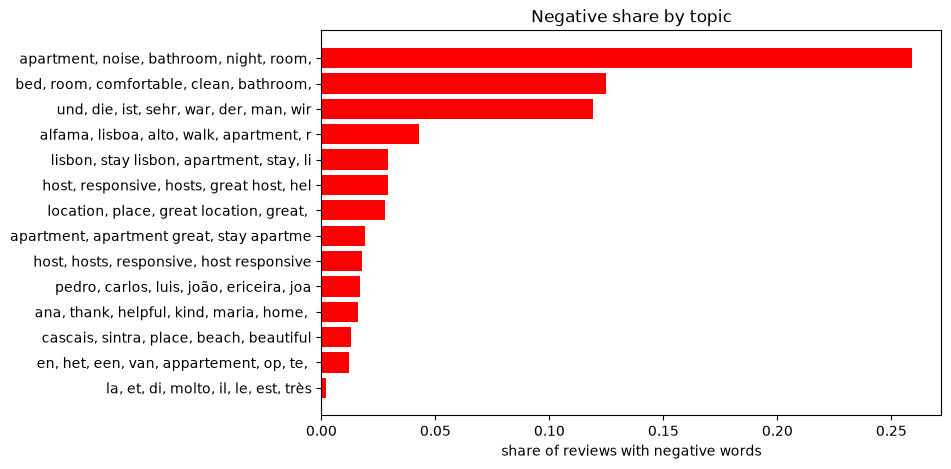

In [12]:
labels, centers = cluster(vectors, n_topics)
reviews["topic"] = labels
reviews["sentiment"] = sentiment(reviews["text"].tolist())
words = topic_words(reviews["text"].tolist(), labels, n_topics)
table = topic_table(reviews, words)
print(table.to_string())
plot_topics(table)

In [13]:
by_neighbourhood = neighbourhood_topics(reviews, LISTINGS_PATH)
worst = by_neighbourhood.sort_values("negative_share", ascending=False).head(10)
print(worst.to_string(index=False))
export(reviews, vectors, centers, table, by_neighbourhood)

neighbourhood_cleansed  topic  reviews  negative_share
   Carcavelos e Parede     13       17           0.471
               Colares     13        7           0.429
              Alcntara     13       36           0.361
              Ericeira     13       33           0.333
            So Vicente     13      181           0.331
                 Ajuda     13       35           0.314
               Estrela     13      113           0.301
               Arroios     13      263           0.274
           Misericrdia     13      623           0.268
     Santa Maria Maior     13      827           0.255


saved review artifacts to /srv/data/models
